Mounted at /content/drive
Loading dataset from Drive... This may take a minute.
Successfully loaded 412698 rows.


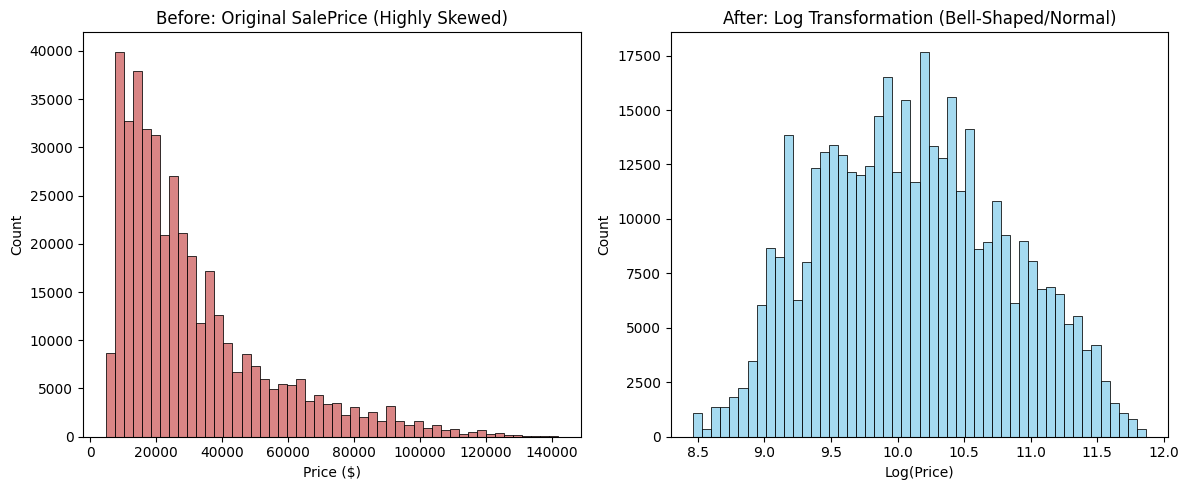


===== MODEL PERFORMANCE =====
RMSE: 0.6545
MAE : 0.5335
R2  : 0.1119


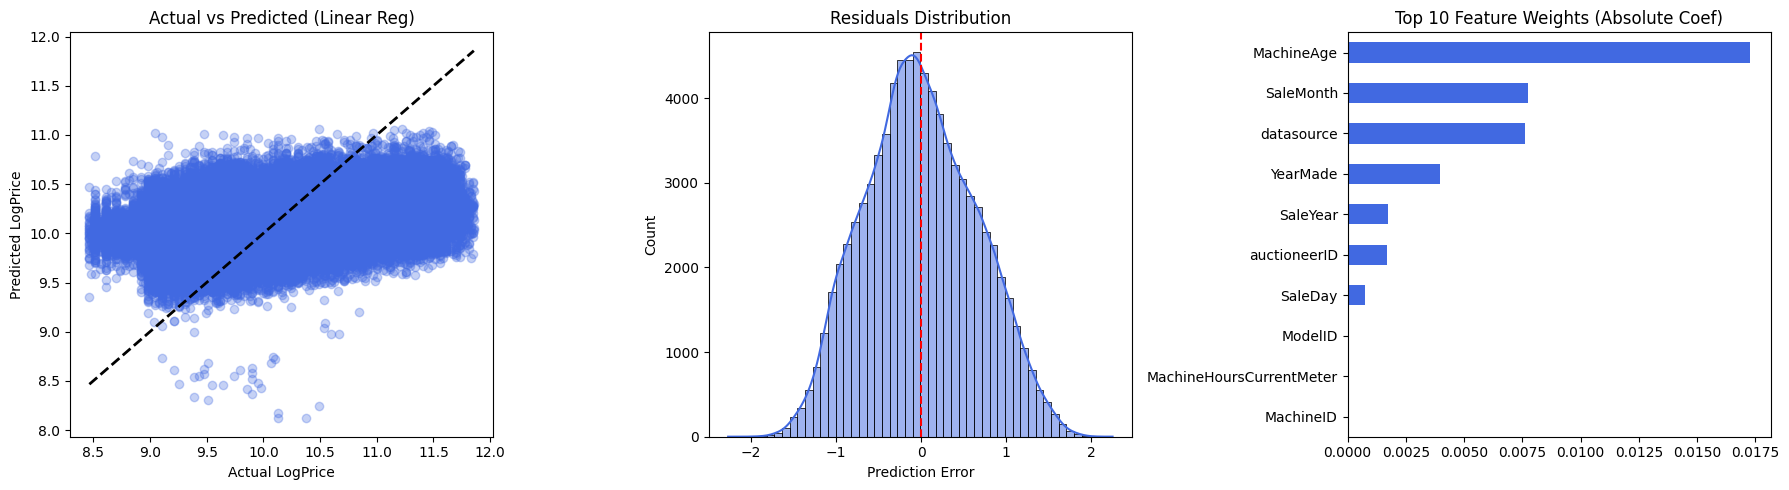

In [ ]:
"""
Group 2
Obil Nathaniel - 271048001
Muhammad Abdullah - 281134982
"""
# ============================
# EXPERIMENT 1: LINEAR REGRESSION (NUMERIC BASELINE)
# ============================
"""
OVERVIEW: This notebook establishes a starting 'baseline' score using a
simple linear model that only looks at numeric data.

STEPS:
1. TARGET SCALING: Used Log Transformation on SalePrice to normalize the
   distribution and handle the wide range of auction prices.
2. DATE PARSING: Extracted Year, Month, and Day from 'saledate' so the
   computer can process time as numbers.
3. DATA CLEANING: Replaced the 'Year 1000' error with NaN and used Median
   Imputation to fill missing values without letting outliers skew the results.
4. FEATURE ENGINEERING: Created 'MachineAge' (SaleYear - YearMade) to
   provide a direct measure of equipment depreciation.

GOAL: To quantify the performance of a basic model before moving to
      advanced ensemble methods.
"""

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# 1. Mount Drive & Load Dataset
# ----------------------------
drive.mount('/content/drive')

# Path updated to 'ML' folder and 'TrainAndValid.csv'
file_path = '/content/drive/MyDrive/ML/TrainAndValid.csv'

print("Loading dataset from Drive... This may take a minute.")
df = pd.read_csv(file_path, low_memory=False)
print(f"Successfully loaded {len(df)} rows.")

# ----------------------------
# 2. Target Transformation & Analysis
# ----------------------------
df['LogPrice'] = np.log(df['SalePrice'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], bins=50, color='indianred')
plt.title('Before: Original SalePrice (Highly Skewed)')
plt.xlabel('Price ($)')

plt.subplot(1, 2, 2)
sns.histplot(df['LogPrice'], bins=50, color='skyblue')
plt.title('After: Log Transformation (Bell-Shaped/Normal)')
plt.xlabel('Log(Price)')
plt.tight_layout()
plt.show()

# ----------------------------
# 3. Feature Engineering & Cleaning
# ----------------------------
# Convert date and extract time features
df['saledate'] = pd.to_datetime(df['saledate'])
df['SaleYear'] = df['saledate'].dt.year
df['SaleMonth'] = df['saledate'].dt.month
df['SaleDay'] = df['saledate'].dt.day
df.drop('saledate', axis=1, inplace=True)

# Fix the 'Year 1000' error and calculate MachineAge
df['YearMade'] = df['YearMade'].replace(1000, np.nan)
df['MachineAge'] = df['SaleYear'] - df['YearMade']

# Baseline logic: Filter to numeric columns and fill missing values with Median
numeric_df = df.select_dtypes(include=np.number)
numeric_df = numeric_df.fillna(numeric_df.median())

# ----------------------------
# 4. Modeling Pipeline
# ----------------------------
X = numeric_df.drop(['SalePrice', 'LogPrice'], axis=1)
y = numeric_df['LogPrice']

# 80/20 Split with fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ----------------------------
# 5. Evaluation & Enhanced Visuals
# ----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n===== MODEL PERFORMANCE =====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

plt.figure(figsize=(18, 5)) # Changed to 18 width for 3 plots

# Plot 1: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual LogPrice")
plt.ylabel("Predicted LogPrice")
plt.title("Actual vs Predicted (Linear Reg)")

# Plot 2: Residuals Distribution
plt.subplot(1, 3, 2)
errors = y_test - y_pred
sns.histplot(errors, bins=50, kde=True, color='royalblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")

# Plot 3: Top 10 Coefficients (Importance)
plt.subplot(1, 3, 3)
# For linear models, we look at the absolute value of the coefficients
coefficients = pd.Series(np.abs(model.coef_), index=X.columns)
coefficients.nlargest(10).sort_values().plot(kind='barh', color='royalblue')
plt.title("Top 10 Feature Weights (Absolute Coef)")

plt.tight_layout()
plt.show()